# Registering custom RLSSM models in HSSM

This is the shortest tutorial in the RLSSM suite. It teaches the **HSSM-native
registry path** for building a reinforcement-learning sequential-sampling model
(RLSSM): you write a learning rule, hand it to `register_rlssm_model()`, and get a
**named, reusable** model configuration you can pull out later with
`get_rlssm_model_config()`.

**Two ways to build an RLSSM — pick based on where you want the model to live:**

| | Define in `ssms.rl`, bridge with `from_ssms_model` | Register HSSM-side with `register_rlssm_model` (this notebook) |
|---|---|---|
| Learning rule lives in | an `ssms.rl` model/learner you author | a function you write in your own code |
| You get | a full simulator **and** a fittable config | a fittable config under a **named key** |
| Best when | you also need to *simulate* the model (data, PPC) | you already have data and just want a named, reusable fitting config |
| Shown in | [Advanced](rlssm_advanced.ipynb), [Restless learner](rlssm_restless_learner.ipynb) | here |

The important thing to notice: **either way, you bring your own learning rule.**
The registry does not hand you a learning function — it wraps *your* function
together with HSSM's decision-process likelihood into one tidy `RLSSMConfig`.

> New to all of this? Start with the [Basic tutorial](rlssm_basic.ipynb), which walks
> through the RLSSM idea, hierarchical priors, recovery, and posterior predictive
> checks in full. Here we assume that background and keep the demonstration light.

## 1. Setup

In [1]:
import logging
import os
import warnings

import arviz as az
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from jax.lax import scan

import hssm
import ssms.rl as rl
from hssm.rl import get_rlssm_model_config, list_models, register_rlssm_model
from hssm.utils import annotate_function  # attaches input/output metadata to a function

warnings.filterwarnings("ignore")
logging.getLogger("jax._src.xla_bridge").setLevel(logging.ERROR)

hssm.set_floatX("float32", update_jax=True)
RANDOM_SEED = 20260707

Setting PyTensor floatX type to float32.


Setting "jax_enable_x64" to False. If this is not intended, please set `jax` to False.


### Simulation scale

In [2]:
# One notebook, two scales. CI executes at the small "doc" scale; the committed
# outputs come from a richer FULL_RUN=1 pass. This notebook is deliberately light,
# so even the full run is smaller than the Basic/Advanced tutorials.
FULL_RUN = os.environ.get("FULL_RUN", "0") == "1"

N_PARTICIPANTS = 12 if FULL_RUN else 4
N_TRIALS = 150 if FULL_RUN else 60
N_CHAINS = 2
N_TUNE = 800 if FULL_RUN else 300
N_DRAWS = 400 if FULL_RUN else 300

print(f"FULL_RUN={FULL_RUN} | participants={N_PARTICIPANTS} trials={N_TRIALS} "
      f"tune={N_TUNE} draws={N_DRAWS}")

FULL_RUN=True | participants=12 trials=150 tune=800 draws=400


## 2. What is already registered?

HSSM ships a few RLSSM templates out of the box. `list_models()` is the discovery
tool; `get_rlssm_model_config(name)` materializes any of them into an `RLSSMConfig`.

In [3]:
for name, description in list_models().items():
    print(f"{name:28s} {description}")

# Peek at one built-in template.
builtin = get_rlssm_model_config("2AB_RescorlaWagner_Angle")
print("\ndecision_process :", builtin.decision_process)
print("computed by learner:", set(builtin.ssm_logp_func.computed))  # {'v'}
print("sampled parameters :", builtin.list_params)

2AB_RescorlaWagner_DDM       RLSSM model with Rescorla-Wagner Q-learning and the standard DDM as decision process.
2AB_RescorlaWagner_Angle     RLSSM model with Rescorla-Wagner Q-learning and a collapsing-bound DDM (angle model) as decision process.
2AB_RescorlaWagner_Weibull   RLSSM model with Rescorla-Wagner Q-learning and a Weibull-bound DDM as decision process.



decision_process : angle
computed by learner: {'v'}
sampled parameters : ['rl_alpha', 'scaler', 'a', 'z', 't', 'theta']


## 3. Write your own learning rule

To register a model we need a **learning function** — the rule that turns trial-by-trial
experience into a decision parameter. Here we implement the classic **Rescorla–Wagner (RW)**
update for a two-armed bandit and use it to drive the diffusion **drift rate `v`**:

- Each arm has an expected value `q`. Before the choice, the drift is the value
  *difference* scaled by a gain: `v = (q_high - q_low) * scaler`.
- After feedback `r`, the chosen arm's value moves toward the outcome by the learning
  rate: `q_chosen += rl_alpha * (r - q_chosen)`.

Two contract details matter for the function to plug into HSSM's registry:

1. **Signature.** A learning function receives one array of shape `(n_trials, 4)` whose
   columns are, *in order*, the four inputs we declare below:
   `["rl_alpha", "scaler", "response", "feedback"]`. It returns the computed `v` for every
   trial. We use `jax.lax.scan` so the whole thing is JAX-differentiable (HSSM needs
   gradients for NUTS).
2. **Response coding.** The `2AB_RW_Angle` simulator codes responses as `-1`/`+1` (which
   diffusion boundary was hit). The learner needs a **0-based arm index** to look up and
   update `q`, so we map `response > 0 → arm 1`, else `arm 0`. *This mapping is on you:*
   HSSM passes the raw `response` column straight through to your function.

In [4]:
def rw_trial(q, row):
    "One Rescorla-Wagner trial: emit the pre-update drift, then update the chosen arm."
    rl_alpha, scaler, response, feedback = row
    arm = jnp.astype(response > 0, jnp.int32)      # -1 -> arm 0, +1 -> arm 1
    v = (q[1] - q[0]) * scaler                     # drift BEFORE this trial's update
    delta = feedback - q[arm]                      # reward prediction error
    q = q.at[arm].set(q[arm] + rl_alpha * delta)   # RW value update
    return q, v


@annotate_function(inputs=["rl_alpha", "scaler", "response", "feedback"], outputs=["v"])
def compute_v(subject_trials):
    "Rescorla-Wagner drift for one participant. Input: (n_trials, 4); output: (n_trials,)."
    q0 = jnp.ones(2) * 0.5                          # both arms start at value 0.5
    _, v = scan(rw_trial, q0, subject_trials)
    return v


# `annotate_function` only attaches metadata (.inputs / .outputs) that the registry reads
# to wire columns to arguments -- it does not change how the function is called.
print("inputs :", compute_v.inputs)
print("outputs:", compute_v.outputs)

inputs : ['rl_alpha', 'scaler', 'response', 'feedback']
outputs: ['v']


## 4. Register the model (the recommended HSSM-side path)

`register_rlssm_model()` stores everything the fitter needs under one name. Register once;
retrieve anywhere with `get_rlssm_model_config()`. Every argument is commented below.

In [5]:
MODEL_NAME = "tutorial_2AB_RW_Angle"

if MODEL_NAME not in list_models():
    register_rlssm_model(
        name=MODEL_NAME,
        decision_process="angle",              # built-in HSSM SSM likelihood (collapsing-bound DDM)
        learning_process={"v": compute_v},     # our function computes the drift `v`
        learning_process_params=["rl_alpha", "scaler"],   # the RL params we will fit
        learning_process_bounds={              # supported ranges for those RL params
            "rl_alpha": (0.0, 1.0),
            "scaler": (0.0, 10.0),
        },
        learning_process_params_default=[0.2, 2.0],       # aligned with learning_process_params
        extra_fields=["feedback"],             # data column the learner needs beyond rt/response
        choices=[-1, 1],                       # response coding for the DECISION side; the
                                               # angle default is [0, 1] and would mislabel our data
        description="Tutorial RW + angle RLSSM registered entirely HSSM-side.",
    )

config = get_rlssm_model_config(MODEL_NAME)
print("sampled parameters:", config.list_params)     # [rl_alpha, scaler, a, z, t, theta]
print("computed by learner:", set(config.ssm_logp_func.computed))  # {'v'}
config

sampled parameters: ['rl_alpha', 'scaler', 'a', 'z', 't', 'theta']
computed by learner: {'v'}


RLSSMConfig(model_name='tutorial_2AB_RW_Angle', description='Tutorial RW + angle RLSSM registered entirely HSSM-side.', response=['rt', 'response'], choices=(-1, 1), list_params=['rl_alpha', 'scaler', 'a', 'z', 't', 'theta'], bounds={'rl_alpha': (0.0, 1.0), 'scaler': (0.0, 10.0), 'a': (0.3, 3.0), 'z': (0.1, 0.9), 't': (0.001, 2.0), 'theta': (-0.1, 1.3)}, loglik=None, loglik_kind='approx_differentiable', backend=None, extra_fields=['feedback'], rv=None, decision_process_loglik_kind='approx_differentiable', learning_process_kind='blackbox', params_default=[0.2, 2.0, 1.65, 0.5, 1.0005, 0.6], decision_process='angle', learning_process={'v': <function compute_v at 0x125f9f7e0>}, ssm_logp_func=<function make_jax_matrix_logp_funcs_from_onnx.<locals>.logp at 0x108c22e80>)

## 5. Simulate data to fit

The registry gives us a **fitting** config. It does not simulate — so to get some data
(and to run a posterior predictive check later) we still use the `ssms.rl` simulator for
the matching preset. Our registered learner reproduces this preset's Rescorla–Wagner rule
exactly, so the two agree.

We reuse the Basic tutorial's ground-truth parameters (small `rl_alpha` for a gradual,
visible learning curve) and draw per-participant values around them.

In [6]:
ssms_config = rl.preset.get("2AB_RW_Angle")

GROUP_THETA = {
    "rl_alpha": 0.08,   # learning rate (small -> gradual, visible learning)
    "scaler": 2.5,      # value-difference -> drift gain
    "a": 1.2,           # boundary separation
    "z": 0.5,           # starting-point bias (0.5 = unbiased)
    "t": 0.25,          # non-decision time (s)
    "theta": 0.35,      # boundary-collapse angle
}
SDS = {"rl_alpha": 0.03, "scaler": 0.40, "a": 0.20, "z": 0.06, "t": 0.05, "theta": 0.10}
BOUNDS = {"rl_alpha": (0.01, 1.0), "scaler": (0.1, 5.0), "a": (0.3, 2.5),
          "z": (0.1, 0.9), "t": (0.05, 1.0), "theta": (0.0, 1.2)}
LIST_PARAMS = list(GROUP_THETA)

rng = np.random.default_rng(RANDOM_SEED)
theta_arrays = {
    name: np.clip(rng.normal(GROUP_THETA[name], SDS[name], N_PARTICIPANTS), *BOUNDS[name])
    for name in LIST_PARAMS
}
true_params = pd.DataFrame(theta_arrays)
true_params.index.name = "participant_id"

data = rl.Simulator(ssms_config).simulate(
    theta=theta_arrays, n_trials=N_TRIALS, n_participants=N_PARTICIPANTS,
    random_state=RANDOM_SEED,
)
print("rows:", len(data), "| columns:", list(data.columns))
data.head()

rows: 1800 | columns: ['participant_id', 'trial_id', 'rt', 'response', 'feedback']


,participant_id,trial_id,rt,response,feedback
0,0,0,1.397879,-1,1.0
1,0,1,0.424477,-1,0.0
2,0,2,0.498285,-1,1.0
3,0,3,1.050406,-1,0.0
4,0,4,1.527007,-1,1.0


## 6. Fit with the registered config

The only new argument versus the Basic tutorial is `model_config=config` — the config we
just pulled from the registry. Everything else is the standard hierarchical RLSSM recipe:
identity links, a `TruncatedNormal` group intercept plus a per-participant random effect
for each parameter, and `process_initvals=False` (mandatory — without it NUTS collapses to
the float32 step-size floor and the posterior never leaves the prior).

In [7]:
PARTICIPANT_EFFECT_PRIOR = {
    "name": "Normal", "mu": 0, "sigma": {"name": "HalfNormal", "sigma": 0.5},
}


def hierarchical_param(name, lower, upper, mu, sigma):
    "A group intercept (TruncatedNormal) + per-participant random effect."
    return hssm.Param(
        name,
        formula=f"{name} ~ 1 + (1|participant_id)",
        prior={
            "Intercept": hssm.Prior("TruncatedNormal", lower=lower, upper=upper,
                                     mu=mu, sigma=sigma),
            "1|participant_id": PARTICIPANT_EFFECT_PRIOR,
        },
    )


model = hssm.RLSSM(
    data=data,
    model_config=config,          # <- the registered, named config
    p_outlier=0,
    lapse=None,
    process_initvals=False,       # mandatory for RLSSM sampling stability
    include=[
        hierarchical_param("rl_alpha", 0.01, 1.0, 0.15, 0.15),
        hierarchical_param("scaler", 0.1, 5.0, 2.0, 0.8),
        hierarchical_param("a", 0.3, 2.5, 1.1, 0.3),
        hierarchical_param("z", 0.1, 0.9, 0.5, 0.15),
        hierarchical_param("t", 0.05, 1.0, 0.25, 0.1),
        hierarchical_param("theta", 0.0, 1.2, 0.35, 0.15),
    ],
)
print("free parameters:", list(model.params.keys()))
assert "v" not in model.params    # v is computed by our learner, never sampled

You supplied a model 'tutorial_2AB_RW_Angle', which is currently not supported in the ssm_simulators package. An error will be thrown when sampling from the random variable or when using any posterior or prior predictive sampling methods.


Model initialized successfully.


free parameters: ['rl_alpha', 'scaler', 'a', 'z', 't', 'theta']


In [8]:
idata = model.sample(
    sampler="numpyro",
    draws=N_DRAWS, tune=N_TUNE, chains=N_CHAINS, cores=N_CHAINS,
    target_accept=0.9, random_seed=RANDOM_SEED,
)
idata

Using default initvals. 



  0%|          | 0/1200 [00:00<?, ?it/s]

warmup:   0%|          | 1/1200 [00:01<22:02,  1.10s/it, 1 steps of size 1.95e+00. acc. prob=0.00]

warmup:   1%|          | 12/1200 [00:01<01:28, 13.37it/s, 6 steps of size 3.91e-03. acc. prob=0.69]

warmup:   2%|▏         | 19/1200 [00:01<01:40, 11.74it/s, 127 steps of size 1.65e-02. acc. prob=0.79]

...

 26%|██▌       | 207/800 [00:00<00:00, 1209.09it/s]

 52%|█████▏    | 415/800 [00:00<00:00, 1603.13it/s]

 78%|███████▊  | 625/800 [00:00<00:00, 1798.52it/s]

100%|██████████| 800/800 [00:00<00:00, 1650.58it/s]

Inference data with groups:
	> posterior
	> log_likelihood
	> sample_stats
	> observed_data

## 7. Group-level recovery

A light check that the fit found the truth: the group intercept (posterior mean + 94% HDI)
against each true group mean. For a full **per-participant** recovery treatment see the
[Basic](rlssm_basic.ipynb) and [Advanced](rlssm_advanced.ipynb) tutorials — we keep this one
short on purpose.

max r-hat: 1.02


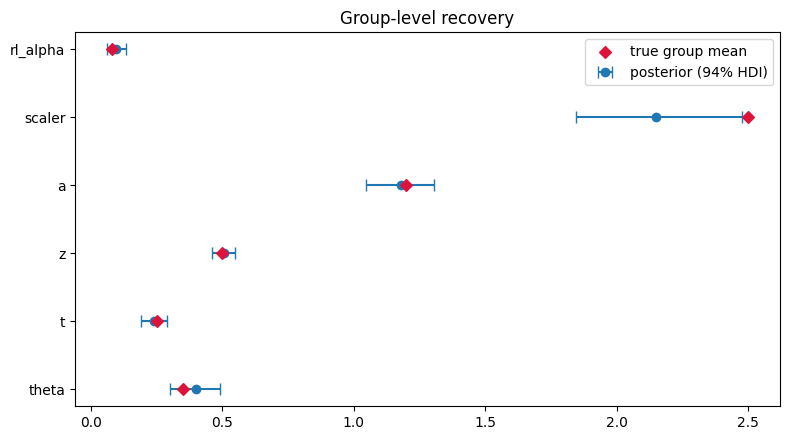

,mean,hdi_3%,hdi_97%,true
rl_alpha,0.095,0.061,0.134,0.08
scaler,2.149,1.844,2.476,2.50
a,1.178,1.047,1.304,1.20
z,0.504,0.461,0.548,0.50
t,0.238,0.189,0.288,0.25
theta,0.401,0.300,0.492,0.35


In [9]:
def group_recovery(idata, true_group):
    "Group intercept posterior vs. true group mean, per parameter."
    names = [f"{p}_Intercept" for p in LIST_PARAMS]
    summ = az.summary(idata, var_names=names, kind="stats")
    summ.index = LIST_PARAMS
    summ["true"] = [true_group[p] for p in LIST_PARAMS]

    fig, ax = plt.subplots(figsize=(8, 4.5))
    y = np.arange(len(LIST_PARAMS))
    ax.errorbar(summ["mean"], y,
                xerr=[summ["mean"] - summ["hdi_3%"], summ["hdi_97%"] - summ["mean"]],
                fmt="o", capsize=4, label="posterior (94% HDI)")
    ax.scatter(summ["true"], y, color="crimson", marker="D", zorder=5,
               label="true group mean")
    ax.set_yticks(y); ax.set_yticklabels(LIST_PARAMS); ax.invert_yaxis()
    ax.set_title("Group-level recovery"); ax.legend()
    fig.tight_layout(); plt.show()
    return summ[["mean", "hdi_3%", "hdi_97%", "true"]].round(3)


print("max r-hat:", float(az.summary(idata)["r_hat"].max()))
group_recovery(idata, GROUP_THETA)

## 8. A quick posterior predictive check

RLSSM-aware PPC re-simulates the learning process **conditioned on the observed
choices and feedback** (`mode="ppc"`), using posterior-mean parameters. We compare one
predicted dataset against the observations along three views: the **learning curve**
(does the fitted model reproduce the climb toward the high-reward arm?), the RT
distribution, and the overall response proportions. A fuller multi-draw PPC lives in the
other tutorials.

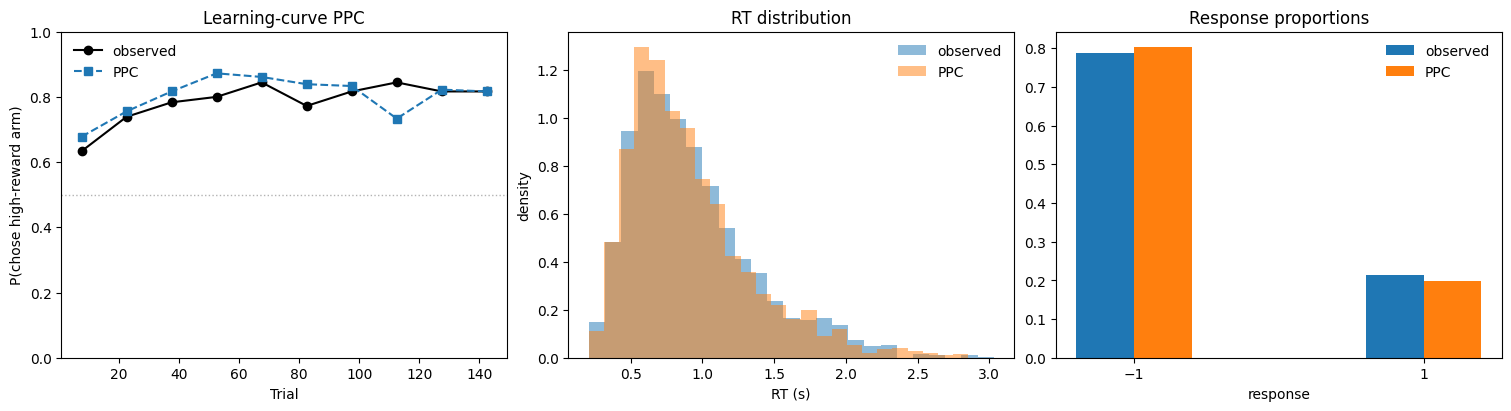

In [10]:
# Posterior-mean per-participant parameters (identity links -> natural scale).
post = idata.posterior
ppc_theta = {}
for name in LIST_PARAMS:
    re = post[f"{name}_1|participant_id"]
    pid_dim = [d for d in re.dims if d not in ("chain", "draw")][0]
    per_p = (post[f"{name}_Intercept"] + re).mean(("chain", "draw"))
    ids = [int(v) for v in re[pid_dim].values]
    ppc_theta[name] = pd.Series(np.asarray(per_p.values), index=ids).sort_index().to_numpy()

ppc = rl.Simulator(ssms_config).simulate(
    theta=ppc_theta, mode="ppc", observed_data=data, random_state=RANDOM_SEED + 1,
)


def _clean(df):
    "Drop non-finite RTs and sentinel (missed) responses."
    return df[np.isfinite(df["rt"]) & (df["rt"] > 0) & (df["response"] > -900)]


def learning_curve(df, bin_size=15):
    "P(chose the high-reward arm) over trials. The high-reward arm is coded response == -1."
    d = _clean(df).copy()
    d["chose_high"] = (d["response"] == -1).astype(float)
    d["trial_bin"] = (d["trial_id"] // bin_size) * bin_size
    return d.groupby("trial_bin")["chose_high"].mean()


fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

# (a) Learning-curve PPC: does the fit reproduce the climb toward the good arm?
obs_curve, ppc_curve = learning_curve(data), learning_curve(ppc)
axes[0].plot(obs_curve.index + 7.5, obs_curve.values, "o-", color="black", label="observed")
axes[0].plot(ppc_curve.index + 7.5, ppc_curve.values, "s--", color="tab:blue", label="PPC")
axes[0].axhline(0.5, color="0.7", ls=":", lw=1)
axes[0].set(title="Learning-curve PPC", xlabel="Trial",
            ylabel="P(chose high-reward arm)", ylim=(0, 1))
axes[0].legend(frameon=False)

# (b) RT distribution
axes[1].hist(_clean(data)["rt"], bins=25, density=True, alpha=0.5, label="observed")
axes[1].hist(_clean(ppc)["rt"], bins=25, density=True, alpha=0.5, label="PPC")
axes[1].set(title="RT distribution", xlabel="RT (s)", ylabel="density")
axes[1].legend(frameon=False)

# (c) Response proportions
for label, df, off in [("observed", data, -0.2), ("PPC", ppc, 0.2)]:
    props = _clean(df)["response"].value_counts(normalize=True).sort_index()
    axes[2].bar(np.array([-1, 1]) + off, [props.get(-1, 0), props.get(1, 0)],
                width=0.4, label=label)
axes[2].set(title="Response proportions", xticks=[-1, 1], xlabel="response")
axes[2].legend(frameon=False)
plt.show()

## 9. Under the hood: what the registry built

A registered model and a bridged model (`from_ssms_model`) populate the **same**
`RLSSMConfig` slots — the registry is just a named shortcut. The key fields:

- `ssm_logp_func` — the decision likelihood, with `.computed` listing learner-driven params.
- `learning_process` — your `{computed_param: function}` mapping.
- `extra_fields` — data columns the learner needs beyond `rt`/`response`.
- `list_params` — every **sampled** parameter (RL params + non-computed SSM params).

In [11]:
bridged = hssm.rl.RLSSMConfig.from_ssms_model(ssms_config)
print("registry list_params:", config.list_params)
print("bridge   list_params:", bridged.list_params)
print("same sampled parameters:", config.list_params == bridged.list_params)
print("registry extra_fields :", config.extra_fields)
print("registry computed     :", set(config.ssm_logp_func.computed))

registry list_params: ['rl_alpha', 'scaler', 'a', 'z', 't', 'theta']
bridge   list_params: ['rl_alpha', 'scaler', 'a', 'z', 't', 'theta']
same sampled parameters: True
registry extra_fields : ['feedback']
registry computed     : {'v'}


## 10. Summary

- Use `register_rlssm_model()` when you want a **named, reusable** RLSSM config built
  entirely HSSM-side — you supply the learning rule; HSSM supplies the decision likelihood.
- **You own the learning function.** Match its input contract (`(n_trials, 4)` columns in
  the order you declare) and handle the response coding yourself (`choices=[-1, 1]` fixes the
  *decision* side; the arm-index mapping inside the learner fixes the *learning* side).
- To *simulate* a custom model (not just fit it), define it in `ssms.rl` and bridge with
  `from_ssms_model` instead — see the [Advanced](rlssm_advanced.ipynb) and
  [Restless learner](rlssm_restless_learner.ipynb) tutorials.

HSSM also supports **choice-only** RL models (choices without response times). Those are
documented separately once validated for the current release.